# 10. Fine-tuning SigLIP on the strict dataset

This notebook tests whether task-specific fine-tuning can improve the prediction of warmth from artwork images. Unlike previous experiments, where SigLIP was used as a frozen feature extractor, this setup allows the model to adapt its representations to the target variable.

The initial experiment focuses only on warmth, since previous results showed that warmth is more learnable than competence.

In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from transformers import AutoProcessor, AutoModel
from tqdm import tqdm

/home/agrupa-lab/agrupa/IE_capstones/Naji/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading the strict dataset

The fine-tuning experiment uses the strict dataset, since it provides more reliable target values than the neutral-imputed version. Image paths are resolved to absolute paths, and only artworks with valid image files are retained.

In [2]:
# ----------------------------
# Configuration
# ----------------------------
DATASET_CSV = "../Data/Processed/final_dataset_strict.csv"
MODEL_NAME = "google/siglip-base-patch16-224"

BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 1e-5
RANDOM_STATE = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv(DATASET_CSV)

print("Original dataset shape:", df.shape)

RAW_IMAGE_ROOT = Path("/home/agrupa-lab/agrupa/data_raw")

df["full_path"] = df["image_path"].apply(
    lambda p: str(RAW_IMAGE_ROOT / p) if isinstance(p, str) else None
)

df["file_exists"] = df["full_path"].apply(
    lambda p: Path(p).exists() if isinstance(p, str) else False
)

print("Missing images:", int((~df["file_exists"]).sum()))

df = df[df["file_exists"]].copy().reset_index(drop=True)

print("Usable rows:", len(df))
df.head(2)

Using device: cuda
Original dataset shape: (3198, 19)
Missing images: 138
Usable rows: 3060


,cat_no,titulo,autor,escuela_obra,tipo_objeto,datacion,tema,is_religious,is_fauna,century,...,descripcion,animal_cluster,n_descriptores_fila,n_en_diccionario_fila,dirmean_Warmth,n_dirmean_Warmth,dirmean_Competence,n_dirmean_Competence,full_path,file_exists
0,P000002,El juicio de Paris,"Albani, Francesco",Italiana,Pintura,1650 - 1660,NaN,0,1,17th c.,...,"La obra de Francesco Albani, uno de los discíp...",purity,890.0,62.0,0.333333,9,0.7,10,/home/agrupa-lab/agrupa/data_raw/obras/P000002...,True
1,P000006,Sagrada Familia y el cardenal Fernando de Medici,"Allori, Alessandro",Italiana,Pintura,1584,NaN,1,1,16th c.,...,"San José, la Virgen con el Niño en brazos y Sa...",other,148.0,17.0,0.937500,4,0.5,2,/home/agrupa-lab/agrupa/data_raw/obras/P000006...,True


## 2. Train, validation, and test split

The first fine-tuning experiment focuses only on the warmth dimension. The dataset is divided into train, validation, and test sets so that model performance can be monitored during training and evaluated fairly at the end.

In [3]:
# Keep only the columns we need for this experiment
warmth_df = df[["cat_no", "full_path", "dirmean_Warmth"]].copy()

# First split: train+val vs test
train_val_df, test_df = train_test_split(
    warmth_df,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Second split: train vs val
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 1958
Validation size: 490
Test size: 612


## 3. PyTorch dataset and dataloaders

A custom dataset is created to load artwork images together with their warmth labels. The SigLIP processor handles image preprocessing, and dataloaders batch the data efficiently for training and evaluation.

In [4]:
# Load processor
processor = AutoProcessor.from_pretrained(MODEL_NAME)

class WarmthDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.dataframe = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(row["full_path"]).convert("RGB")
        pixel_values = self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        label = torch.tensor(row["dirmean_Warmth"], dtype=torch.float32)

        return {
            "pixel_values": pixel_values,
            "label": label
        }

# Create datasets
train_dataset = WarmthDataset(train_df, processor)
val_dataset = WarmthDataset(val_df, processor)
test_dataset = WarmthDataset(test_df, processor)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 245
Validation batches: 62
Test batches: 77


## 4. Model architecture

The model consists of the pre-trained SigLIP image encoder followed by a small regression head. Unlike previous experiments, the encoder is not frozen, allowing the model to adapt its representations to the warmth prediction task.

In [5]:
class SigLIPRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        # Freeze encoder
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.regressor = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, pixel_values):
        with torch.no_grad():
            # Use vision model directly
            vision_outputs = self.encoder.vision_model(pixel_values=pixel_values)

            if hasattr(vision_outputs, "pooler_output") and vision_outputs.pooler_output is not None:
                features = vision_outputs.pooler_output
            elif hasattr(vision_outputs, "last_hidden_state") and vision_outputs.last_hidden_state is not None:
                features = vision_outputs.last_hidden_state[:, 0, :]
            else:
                raise ValueError("Unexpected output format from SigLIP vision encoder")

        out = self.regressor(features)
        return out.squeeze(-1)


# Initialize model
model = SigLIPRegressor(MODEL_NAME)
model = model.to(device)

print("Model loaded (encoder frozen, vision branch only)")

Loading weights: 100%|██████████| 408/408 [00:00<00:00, 13097.07it/s]


Model loaded (encoder frozen, vision branch only)


## 5. Training setup

The model is trained using mean squared error loss, since warmth is treated as a continuous target. Adam is used as the optimizer, and validation loss is tracked after each epoch to monitor whether fine-tuning is improving the model.

In [6]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [7]:
def run_epoch(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    preds = []
    targets = []

    for batch in tqdm(dataloader, leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(pixel_values)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds.extend(outputs.detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, np.array(preds), np.array(targets)

In [11]:
train_losses = []
val_losses = []
val_r2s = []

best_val_r2 = -1e9
best_state_dict = None
best_epoch = None

TOTAL_EPOCHS = 20

for epoch in range(TOTAL_EPOCHS):
    print(f"\nEpoch {epoch+1}/{TOTAL_EPOCHS}")

    train_loss, _, _ = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_preds, val_targets = run_epoch(model, val_loader, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_r2 = r2_score(val_targets, val_preds)
    val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
    val_r2s.append(val_r2)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")
    print(f"Val R²:     {val_r2:.4f}")
    print(f"Val RMSE:   {val_rmse:.4f}")

    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch + 1

print(f"\nBest epoch: {best_epoch}")
print(f"Best validation R²: {best_val_r2:.4f}")


Epoch 1/20


  0%|          | 0/245 [00:00<?, ?it/s]

Train loss: 0.1442
Val loss:   0.1557
Val R²:     0.0850
Val RMSE:   0.3946

Epoch 2/20


Train loss: 0.1427
Val loss:   0.1552
Val R²:     0.0881
Val RMSE:   0.3939

Epoch 3/20


Train loss: 0.1412
Val loss:   0.1547
Val R²:     0.0907
Val RMSE:   0.3934

Epoch 4/20


...

Train loss: 0.1243
Val loss:   0.1575
Val R²:     0.0742
Val RMSE:   0.3969

Epoch 17/20


Train loss: 0.1238
Val loss:   0.1556
Val R²:     0.0856
Val RMSE:   0.3945

Epoch 18/20


Train loss: 0.1221
Val loss:   0.1566
Val R²:     0.0799
Val RMSE:   0.3957

Epoch 19/20


Train loss: 0.1213
Val loss:   0.1563
Val R²:     0.0815
Val RMSE:   0.3954

Epoch 20/20


Train loss: 0.1200
Val loss:   0.1566
Val R²:     0.0796
Val RMSE:   0.3957

Best epoch: 3
Best validation R²: 0.0907


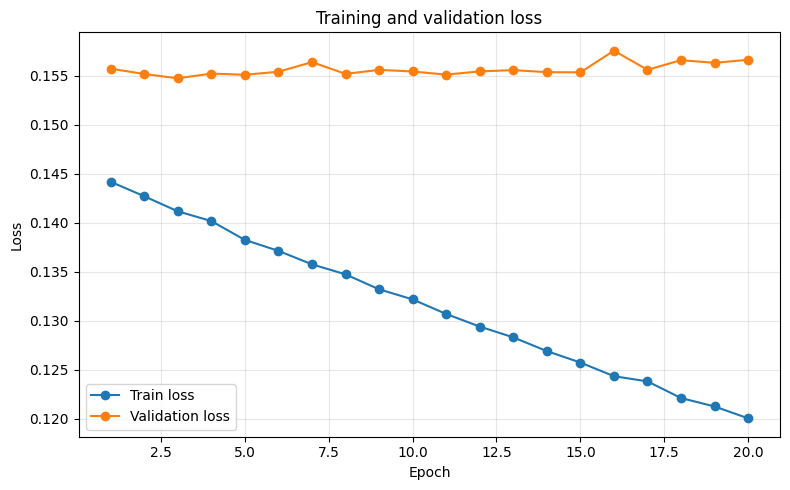

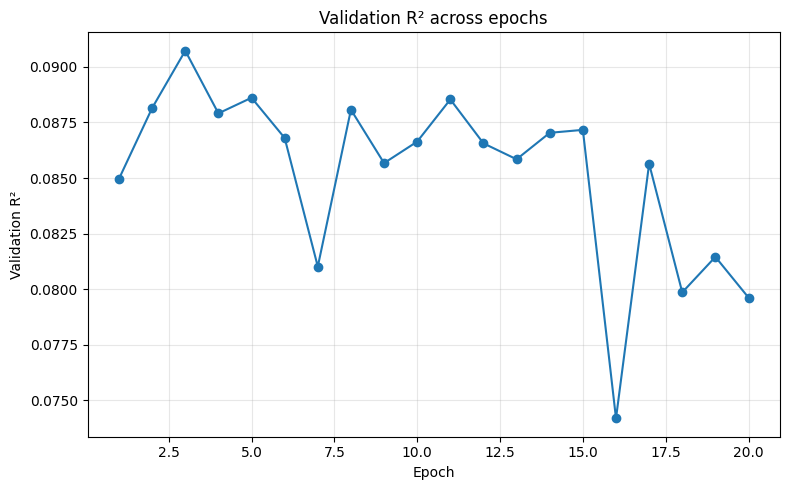

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Train loss")
plt.plot(epochs, val_losses, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_r2s, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation R²")
plt.title("Validation R² across epochs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Alternative fine-tuning setup

To test whether the limited performance is due to the simplicity of the regression head or the sensitivity of the loss function, a second fine-tuning configuration is evaluated.

This alternative setup introduces:
- a deeper regression head
- L2 normalization of the image features before prediction
- SmoothL1 loss instead of MSE

The goal is to determine whether these changes improve generalization on the warmth prediction task.

In [14]:
import copy
import torch.nn.functional as F

class SigLIPRegressorV2(nn.Module):
    def __init__(self, model_name):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        # Keep encoder frozen
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.regressor = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, pixel_values):
        with torch.no_grad():
            vision_outputs = self.encoder.vision_model(pixel_values=pixel_values)

            if hasattr(vision_outputs, "pooler_output") and vision_outputs.pooler_output is not None:
                features = vision_outputs.pooler_output
            elif hasattr(vision_outputs, "last_hidden_state") and vision_outputs.last_hidden_state is not None:
                features = vision_outputs.last_hidden_state[:, 0, :]
            else:
                raise ValueError("Unexpected output format from SigLIP vision encoder")

        # Normalize feature vectors
        features = F.normalize(features, dim=1)

        out = self.regressor(features)
        return out.squeeze(-1)


model_v2 = SigLIPRegressorV2(MODEL_NAME).to(device)
criterion_v2 = nn.SmoothL1Loss()
optimizer_v2 = torch.optim.Adam(model_v2.regressor.parameters(), lr=LEARNING_RATE)

print("Alternative model loaded")

Loading weights: 100%|██████████| 408/408 [00:00<00:00, 13511.53it/s]


Alternative model loaded


In [15]:
def run_epoch_v2(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    preds = []
    targets = []

    for batch in tqdm(dataloader, leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["label"].to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                outputs = model(pixel_values)
                loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds.extend(outputs.detach().cpu().numpy())
        targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss, np.array(preds), np.array(targets)

In [29]:
train_losses_v2 = []
val_losses_v2 = []
val_r2s_v2 = []

best_val_r2_v2 = -1e9
best_state_dict_v2 = None
best_epoch_v2 = None

TOTAL_EPOCHS_V2 = 30

for epoch in range(TOTAL_EPOCHS_V2):
    print(f"\n[Experiment 2] Epoch {epoch+1}/{TOTAL_EPOCHS_V2}")

    train_loss, _, _ = run_epoch_v2(model_v2, train_loader, criterion_v2, optimizer=optimizer_v2)
    val_loss, val_preds, val_targets = run_epoch_v2(model_v2, val_loader, criterion_v2, optimizer=None)

    train_losses_v2.append(train_loss)
    val_losses_v2.append(val_loss)

    val_r2 = r2_score(val_targets, val_preds)
    val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
    val_r2s_v2.append(val_r2)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")
    print(f"Val R²:     {val_r2:.4f}")
    print(f"Val RMSE:   {val_rmse:.4f}")

    if val_r2 > best_val_r2_v2:
        best_val_r2_v2 = val_r2
        best_state_dict_v2 = copy.deepcopy(model_v2.state_dict())
        best_epoch_v2 = epoch + 1

print(f"\nBest epoch (Experiment 2): {best_epoch_v2}")
print(f"Best validation R² (Experiment 2): {best_val_r2_v2:.4f}")


[Experiment 2] Epoch 1/30


Train loss: 0.0142
Val loss:   0.0871
Val R²:     -0.0271
Val RMSE:   0.4181

[Experiment 2] Epoch 2/30


Train loss: 0.0137
Val loss:   0.0867
Val R²:     -0.0232
Val RMSE:   0.4173

[Experiment 2] Epoch 3/30


Train loss: 0.0137
Val loss:   0.0870
Val R²:     -0.0261
Val RMSE:   0.4179

[Experiment 2] Epoch 4/30


Train loss: 0.0133
Val loss:   0.0870
Val R²:     -0.0268
Val RMSE:   0.4180

[Experiment 2] Epoch 5/30


...

Train loss: 0.0104
Val loss:   0.0881
Val R²:     -0.0393
Val RMSE:   0.4205

[Experiment 2] Epoch 27/30


Train loss: 0.0099
Val loss:   0.0878
Val R²:     -0.0357
Val RMSE:   0.4198

[Experiment 2] Epoch 28/30


Train loss: 0.0102
Val loss:   0.0883
Val R²:     -0.0420
Val RMSE:   0.4211

[Experiment 2] Epoch 29/30


Train loss: 0.0100
Val loss:   0.0880
Val R²:     -0.0381
Val RMSE:   0.4203

[Experiment 2] Epoch 30/30


Train loss: 0.0096
Val loss:   0.0880
Val R²:     -0.0376
Val RMSE:   0.4202

Best epoch (Experiment 2): 2
Best validation R² (Experiment 2): -0.0232


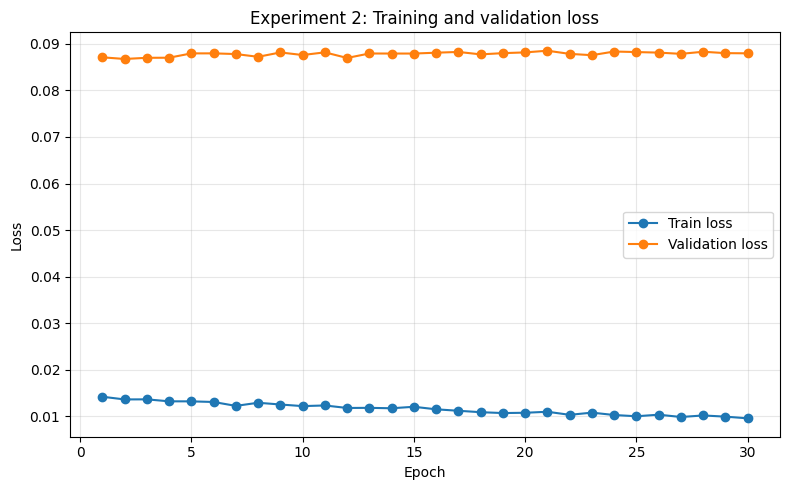

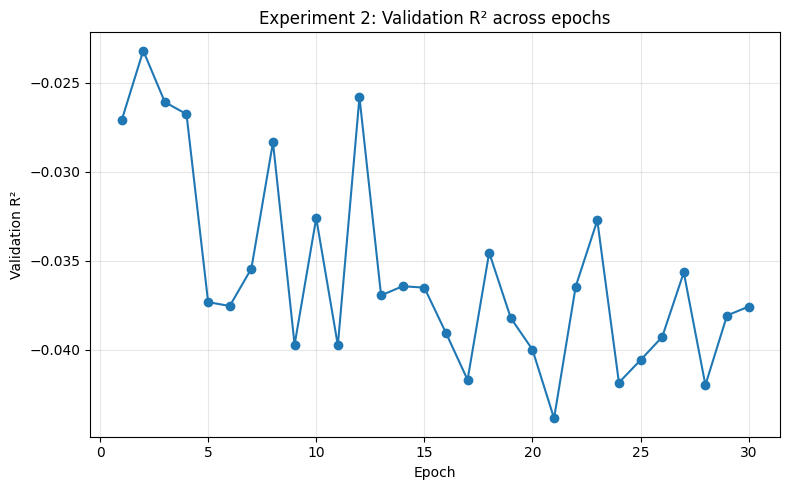

In [30]:
import matplotlib.pyplot as plt

epochs_v2 = range(1, len(train_losses_v2) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_v2, train_losses_v2, marker="o", label="Train loss")
plt.plot(epochs_v2, val_losses_v2, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_v2, val_r2s_v2, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation R²")
plt.title("Experiment 2: Validation R² across epochs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Extending training to 30 epochs shows that the model continues to reduce training loss, but validation performance remains stable and low. Validation R² fluctuates around zero, indicating poor generalization.

This suggests that longer training does not improve performance and that the limitation lies in the weak relationship between visual embeddings and the target variable, rather than in model capacity or optimization.